# Explainable AI (XAI)

In this seminar, we will have a look at some libraries that allow you to get some insights on the model behavior.

We will focus on feature-attribution methods, i.e., given an input $x \in \mathbb{R}^{d_1\times d_2 \times ... d_n}$, a DNN $f: \mathbb{R}^{d_1\times d_2 \times ... d_n} \to \mathbb{R}^{k_1\times k_2 \times ... k_m}$, we provide a heatmap $h \in \mathbb{R}^{d_1\times d_2 \times ... d_n}$ that shows the impact of each element of $x$ on the model output.

In a simple case, $f$ is a classification network and $h$ shows the heatmap of a provided target class of interest.

## SHAP

(Based on [shap documentation](https://shap.readthedocs.io/en/latest/example_notebooks/))

[shap](https://github.com/shap/shap) is a multi-purpose library that can be used for different types of Machine Learning methods, not only for the DNNs. Besides, it can be applied on different modalities. Let's look at the example for text

In [ ]:
!pip install shap transformers datasets

We consider the task of text emotion recognition with a pre-trained BERT model. We are interested in which words\parts of the words had an impact on the model predicted emotion.

In [4]:
import datasets
import pandas as pd
import transformers

# load the emotion dataset
dataset = datasets.load_dataset("emotion", split="train")
data = pd.DataFrame({"text": dataset["text"], "emotion": dataset["label"]})

In [18]:
# load the model and tokenizer
tokenizer = transformers.AutoTokenizer.from_pretrained("nateraw/bert-base-uncased-emotion", use_fast=True)
model = transformers.AutoModelForSequenceClassification.from_pretrained("nateraw/bert-base-uncased-emotion").cuda()

# build a pipeline object to do predictions
pred = transformers.pipeline(
    "text-classification",
    model=model,
    tokenizer=tokenizer,
    device=0,
    top_k=None, # we want to see all scores (for all classes)
)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: nateraw/bert-base-uncased-emotion
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


To explain the model, we need to wrap it with an SHAP `Explainer` class.

In [5]:
import shap

explainer = shap.Explainer(pred)

Let's provide an input for the model

In [21]:
input = data["text"][:3]
input.to_list()

['i didnt feel humiliated',
 'i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake',
 'im grabbing a minute to post i feel greedy wrong']

In [20]:
pred(input.tolist())

[[{'label': 'sadness', 'score': 0.9964079260826111},
  {'label': 'anger', 'score': 0.0012332083424553275},
  {'label': 'joy', 'score': 0.0006807040190324187},
  {'label': 'love', 'score': 0.0006490044179372489},
  {'label': 'fear', 'score': 0.0006467591156251729},
  {'label': 'surprise', 'score': 0.0003823300648946315}],
 [{'label': 'sadness', 'score': 0.9952924251556396},
  {'label': 'fear', 'score': 0.001649439218454063},
  {'label': 'joy', 'score': 0.0011914713541045785},
  {'label': 'love', 'score': 0.0009963022312149405},
  {'label': 'anger', 'score': 0.00046281993854790926},
  {'label': 'surprise', 'score': 0.00040760464617051184}],
 [{'label': 'anger', 'score': 0.9914624094963074},
  {'label': 'sadness', 'score': 0.002277240389958024},
  {'label': 'love', 'score': 0.002076042117550969},
  {'label': 'fear', 'score': 0.001936225569806993},
  {'label': 'surprise', 'score': 0.001564878155477345},
  {'label': 'joy', 'score': 0.000683204794768244}]]

We know the model scores for all classes. Let's now see which words/parts of words influenced these scores. To do so, we pass this input to the explainer wrapper

In [22]:
shap_values = explainer(input)

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
PartitionExplainer explainer: 4it [00:11,  5.77s/it]


Now we can visualize the values

In [25]:
shap.plots.text(shap_values)

Or for a specific class of interest

In [26]:
shap.plots.text(shap_values[:, :, "anger"])

Note that for a dataset-level analysis, we might be interested in the overall impact of a particular word on specific class. `shap` provides some methods to reduce results over the dataset

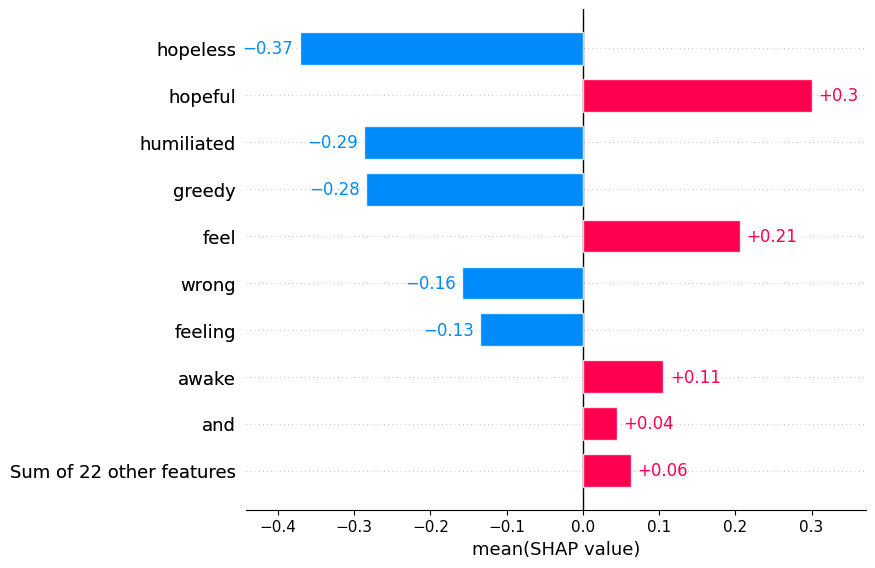

In [27]:
shap.plots.bar(shap_values[:, :, "joy"].mean(0))

## Grad-CAM

(Based on [pytorch grad-cam documentation](https://jacobgil.github.io/pytorch-gradcam-book/introduction.html))

Grad-CAM is another method with its own library [`pytorch_grad_cam`](https://github.com/jacobgil/pytorch-grad-cam). Grad-CAM is a gradient-based method, i.e., the feature attributions are obtained by taking a gradient of the output with respect to input\intermediate features, which are then mapped into original space.

In [ ]:
!pip install grad-cam

In [3]:
import numpy as np
from PIL import Image
import requests
import cv2
import matplotlib.pyplot as plt

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image, preprocess_image
from torchvision.models import resnet50, ResNet50_Weights


model = resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)
model.eval()
image_url = "https://images.unsplash.com/photo-1524061522959-aef54305179e?fm=jpg"
image = Image.open(requests.get(image_url, stream=True).raw)

In [4]:
rgb_img = np.float32(cv2.resize(np.array(image), (512, 512))) / 255
input_tensor = preprocess_image(rgb_img,
                                mean=[0.485, 0.456, 0.406],
                                std=[0.229, 0.224, 0.225])

HORSE_ID = 339
CAR_ID = 817

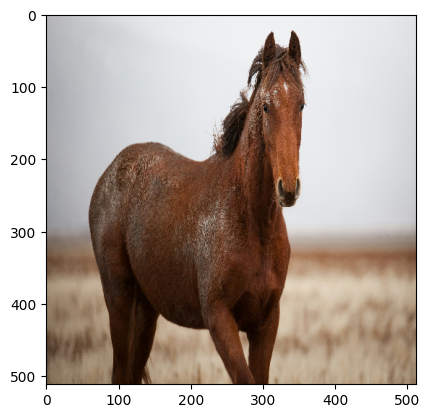

In [5]:
plt.imshow(rgb_img)

In [6]:
model(input_tensor).argmax() # HORSE

tensor(339)

Model believes that the image label is Horse. Let's use Grad-CAM to find why it believes it is a horse

In [7]:
def get_visualization(class_id):
    # We have to specify the target we want to generate the CAM for.
    targets = [ClassifierOutputTarget(class_id)]

    target_layers = [model.layer4[-1]]

    # Construct the CAM object once, and then re-use it on many images.
    with GradCAM(model=model, target_layers=target_layers) as cam:
        # You can also pass aug_smooth=True and eigen_smooth=True, to apply smoothing.
        grayscale_cam = cam(input_tensor=input_tensor, targets=targets)
        # In this example grayscale_cam has only one image in the batch:
        grayscale_cam = grayscale_cam[0, :]
        visualization = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)
        # You can also get the model outputs without having to redo inference
        model_outputs = cam.outputs
    return visualization

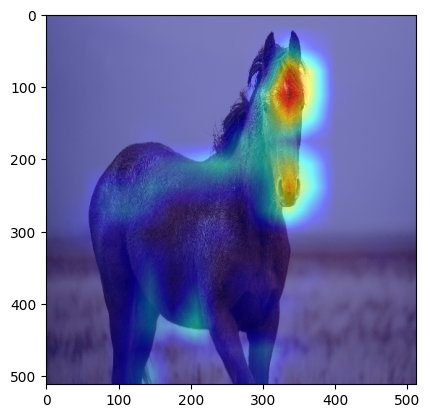

In [8]:
plt.imshow(get_visualization(HORSE_ID))

So, Grad-CAM says that the model looks at the horse head to identify if it is a horse or something else.


Let's look at another example

In [10]:
def get_image_from_url(url):
    """A function that gets a URL of an image,
    and returns a numpy image and a preprocessed
    torch tensor ready to pass to the model """

    img = np.array(Image.open(requests.get(url, stream=True).raw))
    img = cv2.resize(img, (512, 512))
    rgb_img_float = np.float32(img) / 255
    input_tensor = preprocess_image(rgb_img_float,
                                   mean=[0.485, 0.456, 0.406],
                                   std=[0.229, 0.224, 0.225])
    return img, rgb_img_float, input_tensor

In [21]:
image, rgb_img, input_tensor = get_image_from_url("https://images.unsplash.com/photo-1758042531626-f305081ae06d?fm=jpg")

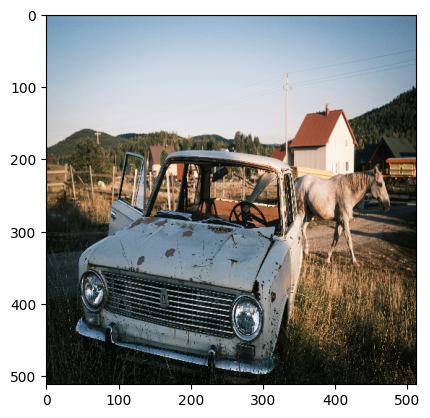

In [22]:
plt.imshow(rgb_img)

We have 2 objects in the image.

We can use feature-attribution as a segmentation\object detection model. For example, the horse-related pixels make the model believe that the image is a horse. So, if we find which elements of the image impact the horse class the most, we can find the horse

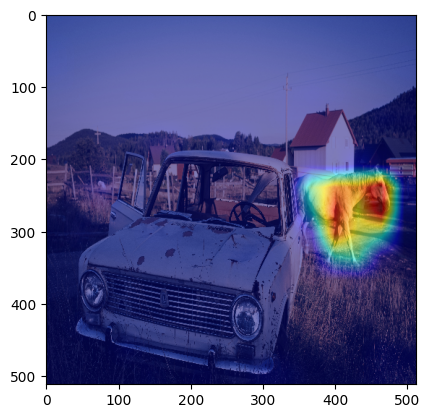

In [23]:
plt.imshow(get_visualization(HORSE_ID))

Or find the car



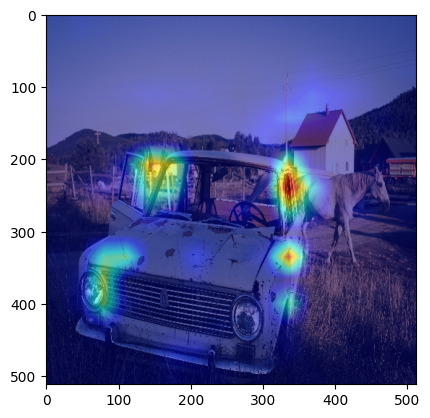

In [27]:
plt.imshow(get_visualization(CAR_ID))

In such a way, you can find objects, whose classes were present within 1000 classes used to train a ResNet. So, for example, we cannot find the "sky" on the image, because ResNet did not have a class "sky".

However, we can replace the classification target with a cosine similarity and compute embeddings using it:

In [35]:
cloud_img, cloud_img_float, cloud_tensor = get_image_from_url("https://images.unsplash.com/photo-1531147646552-1eec68116469?fm=jpg")

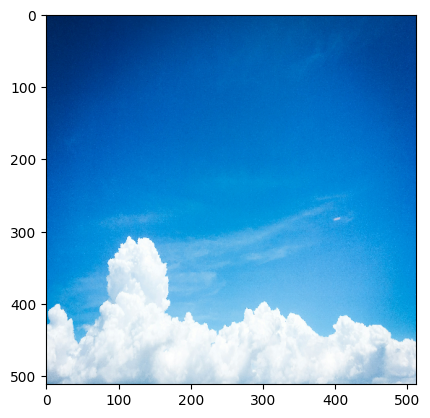

In [36]:
plt.imshow(cloud_img_float)

First, we need to create a wrapper to get an embedding instead of classification score:

In [37]:
import torch

# A model wrapper that gets a resnet model and returns the features before the fully connected layer.
class ResnetFeatureExtractor(torch.nn.Module):
    def __init__(self, model):
        super(ResnetFeatureExtractor, self).__init__()
        self.model = model
        self.feature_extractor = torch.nn.Sequential(*list(self.model.children())[:-1])

    def __call__(self, x):
        return self.feature_extractor(x)[:, :, 0, 0]

In [38]:
model_extractor = ResnetFeatureExtractor(model)

Now we need to say how similar are two images based on the embeddings similarity, which, for example, can be measured as a cosine similarity:

In [39]:
import torch

class SimilarityToConceptTarget:
    def __init__(self, features):
        self.features = features

    def __call__(self, model_output):
        cos = torch.nn.CosineSimilarity(dim=0)
        return cos(model_output, self.features)

In [40]:
cloud_concept_features = model_extractor(cloud_tensor)[0, :]

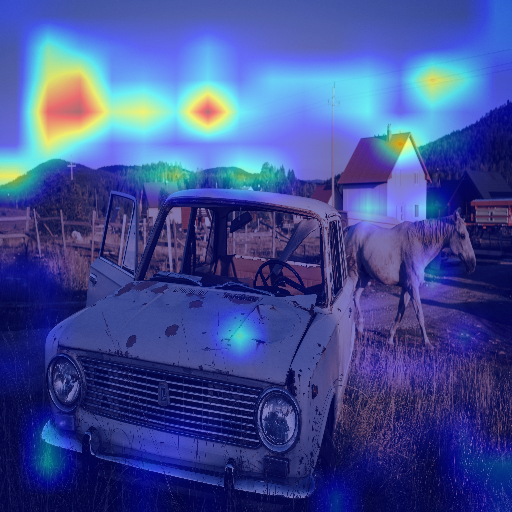

In [41]:
target_layers = [model.layer4[-1]] # we can use original model because model_extractor is linked to the same layer
cloud_targets = [SimilarityToConceptTarget(cloud_concept_features)]

# Where is the cloud in the image
with GradCAM(model=model_extractor, # put extractor here
             target_layers=target_layers) as cam:
    car_grayscale_cam = cam(input_tensor=input_tensor,
                        targets=cloud_targets)[0, :]
cam_image = show_cam_on_image(rgb_img, car_grayscale_cam, use_rgb=True)
Image.fromarray(cam_image)


## Transformer Relevancy

To explain transformers, one can just use raw attention scores. However, this will not account for the layers between attentions and for the target output.

Another option could be to use a "Grad-CAM"-transformer variant, in which gradients are computed with respect to the attention scores instead of convolution feature maps.

However, as shown in [Generic Attention-model Explainability for Interpreting Bi-Modal and Encoder-Decoder Transformers](https://arxiv.org/abs/2103.15679), such an approach achieves suboptimal performance.

A more robust, though still easy-to-use, method proposed in the same paper works as follows:

First, we comput gradients and attention scores for all layers:

$$
\overline{A} = \mathbb{E}_h \left((\nabla A \odot A)^{+}\right)
$$

Then, we initialize a relevancy matrix $R=I$, which shows how each token is relevant to another. Note that the first row\column corresponds to the CLS token.

Then, starting from the last layer, we can iteratively improve $R$:

$$
R = R + \overline{A} \cdot R
$$

After processing each attention layer, we can extract the final relevancy vector for the CLS token: $R[0, 1:]$. Note that one token corresponds to a patch in ViT-style image transformers. So, by reshaping this relevancy vector to a square size and upscaling it back to the image resolution, we get a heatmap for the image

Let's look at the implementation from the authors:  https://github.com/hila-chefer/Transformer-Explainability.git

In [ ]:
!git clone https://github.com/hila-chefer/Transformer-Explainability.git

import os
os.chdir(f'./Transformer-Explainability')

!pip install "Pillow>=8.1.1" einops==0.3.0 h5py imageio==2.9.0 opencv_python \
  scipy torch torchvision tqdm transformers \
  utils==1.0.1 "Pygments>=2.7.4"

Relevancy Vector Computation:

In [ ]:
from PIL import Image
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import torch
import numpy as np
import cv2

In [3]:
# rule 5 from paper
def avg_heads(cam, grad):
    cam = cam.reshape(-1, cam.shape[-2], cam.shape[-1])
    grad = grad.reshape(-1, grad.shape[-2], grad.shape[-1])
    cam = grad * cam
    cam = cam.clamp(min=0).mean(dim=0)
    return cam

# rule 6 from paper
def apply_self_attention_rules(R_ss, cam_ss):
    R_ss_addition = torch.matmul(cam_ss, R_ss)
    return R_ss_addition

def generate_relevance(model, input, index=None):
    output = model(input, register_hook=True)
    if index == None:
        index = np.argmax(output.cpu().data.numpy(), axis=-1)

    one_hot = np.zeros((1, output.size()[-1]), dtype=np.float32)
    one_hot[0, index] = 1
    one_hot_vector = one_hot
    one_hot = torch.from_numpy(one_hot).requires_grad_(True)
    one_hot = torch.sum(one_hot.cuda() * output)
    model.zero_grad()
    one_hot.backward(retain_graph=True)

    num_tokens = model.blocks[0].attn.get_attention_map().shape[-1]
    R = torch.eye(num_tokens, num_tokens).cuda()
    for blk in model.blocks:
        grad = blk.attn.get_attn_gradients()
        cam = blk.attn.get_attention_map()
        cam = avg_heads(cam, grad)
        R += apply_self_attention_rules(R.cuda(), cam.cuda())
    return R[0, 1:]

Let's load the model

In [5]:
from baselines.ViT.ViT_new import vit_base_patch16_224 as vit

normalize = transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    normalize,
])

# create heatmap from mask on image
def show_cam_on_image(img, mask):
    heatmap = cv2.applyColorMap(np.uint8(255 * mask), cv2.COLORMAP_JET)
    heatmap = np.float32(heatmap) / 255
    cam = heatmap + np.float32(img)
    cam = cam / np.max(cam)
    return cam

# initialize ViT pretrained
model = vit(pretrained=True).cuda()
model.eval()

Downloading: "https://github.com/rwightman/pytorch-image-models/releases/download/v0.1-vitjx/jx_vit_base_p16_224-80ecf9dd.pth" to /root/.cache/torch/hub/checkpoints/jx_vit_base_p16_224-80ecf9dd.pth


VisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
  )
  (pos_drop): Dropout(p=0.0, inplace=False)
  (blocks): ModuleList(
    (0-11): 12 x Block(
      (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (attn): Attention(
        (qkv): Linear(in_features=768, out_features=2304, bias=True)
        (attn_drop): Dropout(p=0.0, inplace=False)
        (proj): Linear(in_features=768, out_features=768, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=768, out_features=3072, bias=True)
        (act): GELU(approximate='none')
        (fc2): Linear(in_features=3072, out_features=768, bias=True)
        (drop): Dropout(p=0.0, inplace=False)
      )
    )
  )
  (norm): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
  (head): Linear(in_features=768, out_features=1000, bi

Helper for reshaping and resizing relevancy vector (+ calling its generation)

In [6]:
def generate_visualization(original_image, class_index=None):
    transformer_attribution = generate_relevance(model, original_image.unsqueeze(0).cuda(), index=class_index).detach()
    transformer_attribution = transformer_attribution.reshape(1, 1, 14, 14)
    transformer_attribution = torch.nn.functional.interpolate(transformer_attribution, scale_factor=16, mode='bilinear')
    transformer_attribution = transformer_attribution.reshape(224, 224).cuda().data.cpu().numpy()
    transformer_attribution = (transformer_attribution - transformer_attribution.min()) / (transformer_attribution.max() - transformer_attribution.min())
    image_transformer_attribution = original_image.permute(1, 2, 0).data.cpu().numpy()
    image_transformer_attribution = (image_transformer_attribution - image_transformer_attribution.min()) / (image_transformer_attribution.max() - image_transformer_attribution.min())
    vis = show_cam_on_image(image_transformer_attribution, transformer_attribution)
    vis =  np.uint8(255 * vis)
    vis = cv2.cvtColor(np.array(vis), cv2.COLOR_RGB2BGR)
    return vis

Helper for printing model predictions

In [9]:
from samples.CLS2IDX import CLS2IDX

def print_top_classes(predictions, **kwargs):
    # Print Top-5 predictions
    prob = torch.softmax(predictions, dim=1)
    class_indices = predictions.data.topk(5, dim=1)[1][0].tolist()
    max_str_len = 0
    class_names = []
    for cls_idx in class_indices:
        class_names.append(CLS2IDX[cls_idx])
        if len(CLS2IDX[cls_idx]) > max_str_len:
            max_str_len = len(CLS2IDX[cls_idx])

    print('Top 5 classes:')
    for cls_idx in class_indices:
        output_string = '\t{} : {}'.format(cls_idx, CLS2IDX[cls_idx])
        output_string += ' ' * (max_str_len - len(CLS2IDX[cls_idx])) + '\t\t'
        output_string += 'value = {:.3f}\t prob = {:.1f}%'.format(predictions[0, cls_idx], 100 * prob[0, cls_idx])
        print(output_string)

Let's see the results!

Top 5 classes:
	282 : tiger cat       		value = 10.559	 prob = 68.6%
	281 : tabby, tabby cat		value = 9.059	 prob = 15.3%
	285 : Egyptian cat    		value = 8.414	 prob = 8.0%
	243 : bull mastiff    		value = 7.425	 prob = 3.0%
	811 : space heater    		value = 5.152	 prob = 0.3%


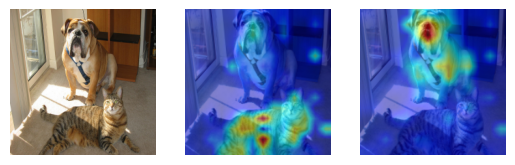

In [10]:
image = Image.open('samples/catdog.png')
dog_cat_image = transform(image)

fig, axs = plt.subplots(1, 3)
axs[0].imshow(image);
axs[0].axis('off');

output = model(dog_cat_image.unsqueeze(0).cuda())
print_top_classes(output)

# cat - the predicted class
cat = generate_visualization(dog_cat_image)

# dog
# generate visualization for class 243: 'bull mastiff'
dog = generate_visualization(dog_cat_image, class_index=243)


axs[1].imshow(cat);
axs[1].axis('off');
axs[2].imshow(dog);
axs[2].axis('off');